In [1]:
import os
from pathlib import Path
import dill as pickle
import epde
import numpy as np
import pandas as pd
import torch
from epde.integrate import OdeintAdapter
from epde.integrate.pinn_integration import SolverAdapter
from scipy import stats
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

with open('data_00_330_[30_bots_PWM_10_15cw_15ccw_D_41cm].MP4.pickle', 'rb') as file:
    data = pickle.load(file)
keys_list = [inner_list[0] for inner_list in data[0]]
dict_variable = {i: [] for i in keys_list}

for inner_list in data[:]:
    for item in inner_list:
        key = item[0]
        value = item[1]
        if key in dict_variable:
            dict_variable[key].append(value)
        else:
            dict_variable[key] = [value]
coord_data = {}

for inner_list in data:
    for item in inner_list:
        key = item[0]
        coordinates = item[2]
        if key in coord_data:
            coord_data[key].append(coordinates)
        else:
            coord_data[key] = [coordinates]


def normalize_to_normal_distribution(data):
    if np.min(data) <= 0:
        data = data - np.min(data) + 1e-6
    transformed_data, lambda_value = stats.boxcox(data)
    scaler = MinMaxScaler(feature_range=(0, 1))
    normalized_data = scaler.fit_transform(transformed_data.reshape(-1, 1)).flatten()

    return normalized_data


normalized_coord_data = {}

all_x = []
all_y = []
for obj_id, points in coord_data.items():
    points = np.array(points)
    all_x.extend(points[:, 0])
    all_y.extend(points[:, 1])

all_x = np.array(all_x)
all_y = np.array(all_y)

x_normalized = normalize_to_normal_distribution(all_x)
y_normalized = normalize_to_normal_distribution(all_y)

idx = 0
for obj_id, points in coord_data.items():
    points = np.array(points)
    num_points = len(points)
    obj_x_norm = x_normalized[idx:idx + num_points]
    obj_y_norm = y_normalized[idx:idx + num_points]
    normalized_points = np.column_stack((obj_x_norm, obj_y_norm))
    normalized_coord_data[obj_id] = normalized_points
    idx += num_points

frequency = 1
object_key = 79
x_object_key_78 = [coord[0] for coord in normalized_coord_data[object_key]][:2750:frequency]
y_object_key_78 = [coord[1] for coord in normalized_coord_data[object_key]][:2750:frequency]
t_object_key_78 = list(range(0, len(normalized_coord_data[object_key])))[:2750:frequency]

#PATH = r'C:\Users\Ksenia\NSS\ODE_projects\robots\new_data\output'
df = pd.read_csv(f'./output/output_{object_key}_part_1.csv', index_col='Unnamed: 0', sep=',', encoding='utf-8')  # READ

most_common_structure = df.groupby(df.columns.tolist()).size().reset_index(name='count')
most_common_structure = most_common_structure.sort_values(by='count', ascending=False)
most_common_structure






,C_x,d^2x/dx0^2{power: 1.0}_x,d^2y/dx0^2{power: 1.0}_x,x{power: 1.0}_x,x{power: 1.0} * dx/dx0{power: 1.0}_x,dx/dx0{power: 1.0}_x,y{power: 1.0}_x,"t{power: 1.0, dim: 0.0}_x",dy/dx0{power: 1.0}_x,y{power: 1.0}_y,d^2x/dx0^2{power: 1.0}_y,C_y,"d^2y/dx0^2{power: 1.0} * t{power: 1.0, dim: 0.0}_y","t{power: 1.0, dim: 0.0}_y",dy/dx0{power: 1.0}_y,x{power: 1.0}_y,"t{power: 1.0, dim: 0.0} * dy/dx0{power: 1.0}_y",d^2y/dx0^2{power: 1.0}_y,count
0,-0.000063,0.0,0.0,0.000075,1.218098,-1.0,0.0,0.0,0.000000,-0.150201,0.0,0.102982,-1.0,0.0,0.0,0.000000,0.0,0.0,1
1,-0.000063,0.0,0.0,0.000075,1.218098,-1.0,0.0,0.0,0.000000,0.000000,0.0,0.016014,0.0,0.0,-1.0,-0.019776,0.0,0.0,1
2,0.000000,-1.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,-0.150201,0.0,0.102982,-1.0,0.0,0.0,0.000000,0.0,0.0,1
3,0.001012,-1.0,0.0,-0.001204,0.000000,0.0,0.0,0.0,0.043827,0.000000,0.0,0.000000,0.0,0.0,-1.0,0.000000,0.0,0.0,1
4,0.001713,-1.0,0.0,-0.002070,0.000000,0.0,0.0,0.0,0.000000,-0.150201,0.0,0.102982,-1.0,0.0,0.0,0.000000,0.0,0.0,1
5,0.001713,-1.0,0.0,-0.002070,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,7.295939,0.0,0.0,0.0,-8.986016,-1.0,0.0,1


In [2]:
zero_coefficients = (df == 0)
zero_patterns = zero_coefficients.astype(int).astype(str).agg(''.join, axis=1)
pattern_counts = zero_patterns.value_counts()
most_common_pattern = pattern_counts.idxmax()
count_of_most_common_pattern = pattern_counts.max()
print(f"Zero pattern is: {most_common_pattern}")
print(f"It appears {count_of_most_common_pattern} times.")

Zero pattern is: 001011111010011111
It appears 1 times.


In [3]:

scaler = StandardScaler()
normalized_df = scaler.fit_transform(df.values)
df_normalized = pd.DataFrame(normalized_df, columns=df.columns, index=df.index)
df_filtered = df_normalized.loc[(df.sum(axis=1) != -1)]
df_filtered = df_filtered.loc[:, (df_filtered != 0).any(axis=0)]
df_filtered

,C_x,d^2x/dx0^2{power: 1.0}_x,x{power: 1.0}_x,x{power: 1.0} * dx/dx0{power: 1.0}_x,dx/dx0{power: 1.0}_x,dy/dx0{power: 1.0}_x,y{power: 1.0}_y,C_y,"d^2y/dx0^2{power: 1.0} * t{power: 1.0, dim: 0.0}_y",dy/dx0{power: 1.0}_y,x{power: 1.0}_y,"t{power: 1.0, dim: 0.0} * dy/dx0{power: 1.0}_y"
0,1.249371,-0.707107,-1.254129,-0.707107,0.707107,-0.447214,-1.0,-0.433062,-1.0,0.707107,0.448394,0.447214
1,-0.981663,1.414214,0.979262,1.414214,-1.414214,-0.447214,1.0,-0.465330,1.0,-1.414214,0.442486,0.447214
2,-0.981663,1.414214,0.979262,1.414214,-1.414214,-0.447214,-1.0,-0.433062,-1.0,0.707107,0.448394,0.447214
3,1.249371,-0.707107,-1.254129,-0.707107,0.707107,-0.447214,1.0,2.235787,1.0,0.707107,-2.236063,-2.236068
4,-0.903115,-0.707107,0.901489,-0.707107,0.707107,-0.447214,-1.0,-0.433062,-1.0,0.707107,0.448394,0.447214
5,0.367700,-0.707107,-0.351756,-0.707107,0.707107,2.236068,1.0,-0.471272,1.0,-1.414214,0.448394,0.447214


In [4]:
num_samples = 100
monte_carlo_samples = pd.DataFrame(index=df.index, columns=df.columns)
print('monte_carlo_samples', monte_carlo_samples.shape)
for column in df.columns:
    mean_value = df[column].mean()
    std_dev = df[column].std()
    min_value = df[column].min()
    max_value = df[column].max()
    for i in range(num_samples):
        current_mean = df[column].iloc[i % df.shape[0]]
        current_std_dev = std_dev * 0.01
        noise = np.random.normal(loc=0, scale=current_std_dev)
        sample = current_mean + noise
        sample = np.clip(sample, min_value, max_value)
        monte_carlo_samples.loc[i, column] = sample

monte_carlo_samples = monte_carlo_samples.dropna()
distances = pairwise_distances(df, monte_carlo_samples)
threshold = 1.
similar_rows = []
for j in range(distances.shape[1]):
    # for i in range(distances.shape[0]):
    if distances[0][j] < threshold:
        similar_rows.append(monte_carlo_samples.iloc[j])
        # break
# for i in range(distances.shape[0]):

new_coeff = pd.DataFrame(similar_rows)
new_coeff.columns = monte_carlo_samples.columns
new_coeff

monte_carlo_samples (6, 18)


,C_x,d^2x/dx0^2{power: 1.0}_x,d^2y/dx0^2{power: 1.0}_x,x{power: 1.0}_x,x{power: 1.0} * dx/dx0{power: 1.0}_x,dx/dx0{power: 1.0}_x,y{power: 1.0}_x,"t{power: 1.0, dim: 0.0}_x",dy/dx0{power: 1.0}_x,y{power: 1.0}_y,d^2x/dx0^2{power: 1.0}_y,C_y,"d^2y/dx0^2{power: 1.0} * t{power: 1.0, dim: 0.0}_y","t{power: 1.0, dim: 0.0}_y",dy/dx0{power: 1.0}_y,x{power: 1.0}_y,"t{power: 1.0, dim: 0.0} * dy/dx0{power: 1.0}_y",d^2y/dx0^2{power: 1.0}_y
0,1.713427e-03,-1.000000,0.0,-0.002054,0.012856,0.000000,0.0,0.0,0.000000,-0.150201,0.0,0.074315,-0.999893,0.0,-0.011368,0.000000,-0.001929,0.0
4,-9.320545e-06,-1.000000,0.0,-0.000001,0.000000,0.000000,0.0,0.0,0.000112,-0.149882,0.0,0.055131,-0.999093,0.0,-0.000357,-0.014999,-0.006769,0.0
6,1.713427e-03,-1.000000,0.0,-0.002070,0.004021,0.000000,0.0,0.0,0.000029,-0.148293,0.0,0.136842,-1.000000,0.0,0.000000,-0.044686,-0.001571,0.0
10,9.352537e-06,-0.995872,0.0,-0.000016,0.000000,0.000000,0.0,0.0,0.000155,-0.149755,0.0,0.144045,-1.000000,0.0,-0.000078,-0.022774,-0.001868,0.0
12,1.713427e-03,-1.000000,0.0,-0.002064,0.000000,-0.004657,0.0,0.0,0.000000,-0.149775,0.0,0.073266,-1.000000,0.0,0.000000,-0.005805,-0.001766,0.0
16,8.048593e-06,-1.000000,0.0,0.000002,0.005797,-0.006792,0.0,0.0,0.000130,-0.149620,0.0,0.101744,-0.994477,0.0,-0.001683,-0.031371,-0.002119,0.0
18,1.703372e-03,-0.997982,0.0,-0.002070,0.000000,-0.003542,0.0,0.0,0.000040,-0.148705,0.0,0.117491,-1.000000,0.0,0.000000,0.000000,-0.000379,0.0
22,-1.176492e-05,-1.000000,0.0,0.000008,0.000000,-0.000598,0.0,0.0,0.000000,-0.149988,0.0,0.108525,-1.000000,0.0,0.000000,-0.023250,-0.006001,0.0
24,1.711772e-03,-1.000000,0.0,-0.002070,0.000000,-0.001185,0.0,0.0,0.000186,-0.149147,0.0,0.148398,-1.000000,0.0,-0.003957,0.000000,-0.001110,0.0
28,1.465611e-05,-0.998835,0.0,-0.000003,0.000000,-0.004052,0.0,0.0,0.000049,-0.149049,0.0,0.107852,-0.998101,0.0,0.000000,0.000000,-0.001908,0.0


In [5]:
first_row = new_coeff.iloc[0]

# Фильтруем колонки с ненулевыми элементами
nonzero_columns = first_row[first_row != 0].index.tolist()

print(nonzero_columns)

['C_x', 'd^2x/dx0^2{power: 1.0}_x', 'x{power: 1.0}_x', 'x{power: 1.0} * dx/dx0{power: 1.0}_x', 'y{power: 1.0}_y', 'C_y', 'd^2y/dx0^2{power: 1.0} * t{power: 1.0, dim: 0.0}_y', 'dy/dx0{power: 1.0}_y', 't{power: 1.0, dim: 0.0} * dy/dx0{power: 1.0}_y']


In [6]:
distances.shape

(6, 100)

In [7]:
def construct_equation_dict(new_coeff):
    equations = []
    for index, row in new_coeff.iterrows():
        first_dict = {}
        second_dict = {}
        third_dict = {}
        first_dict ={
            # --- Terms for X equation ---
            'C_x': {'coeff': row.get('C_x', 0), 'term': [[None]], 'pow': [1], 'var': [0]},
            'x_x': {'coeff': row.get('x{power: 1.0}_x', 0), 'term': [[None]], 'pow': [1], 'var': [0]},
            'y_x': {'coeff': row.get('y{power: 1.0}_x', 0), 'term': [[None]], 'pow': [1], 'var': [1]},
            'dx/dt_x': {'coeff': row.get('dx/dx0{power: 1.0}_x', 0), 'term': [[0]], 'pow': [1], 'var': [0]},
            'd^2x/dt^2_x': {'coeff': row.get('d^2x/dx0^2{power: 1.0}_x', 0), 'term': [[0, 0]], 'pow': [1], 'var': [0]},
            'dy/dt_x': {'coeff': row.get('dy/dx0{power: 1.0}_x', 0), 'term': [[0]], 'pow': [1], 'var': [1]},
            'd^2y/dt^2_x': {'coeff': row.get('d^2y/dx0^2{power: 1.0}_x', 0), 'term': [[0, 0]], 'pow': [1], 'var': [1]},
            't_x': {'coeff': row.get('t{power: 1.0, dim: 0.0}_x', 0), 'term': [[None]], 'pow': [1], 'var': [0],
                    'grid_term': True},
            't^2_x': {'coeff': row.get('t{power: 2.0, dim: 0.0}_x', 0), 'term': [[None]], 'pow': [2], 'var': [0],
                      'grid_term': True},

            # --- Terms for Y equation ---
            'C_y': {'coeff': row.get('C_y', 0), 'term': [[None]], 'pow': [1], 'var': [0]},
            'x_y': {'coeff': row.get('x{power: 1.0}_y', 0), 'term': [[None]], 'pow': [1], 'var': [0]},
            'y_y': {'coeff': row.get('y{power: 1.0}_y', 0), 'term': [[None]], 'pow': [1], 'var': [1]},
            'dx/dt_y': {'coeff': row.get('dx/dx0{power: 1.0}_y', 0), 'term': [[0]], 'pow': [1], 'var': [0]},
            'd^2x/dt^2_y': {'coeff': row.get('d^2x/dx0^2{power: 1.0}_y', 0), 'term': [[0, 0]], 'pow': [1], 'var': [0]},
            'dy/dt_y': {'coeff': row.get('dy/dx0{power: 1.0}_y', 0), 'term': [[0]], 'pow': [1], 'var': [1]},
            'd^2y/dt^2_y': {'coeff': row.get('d^2y/dx0^2{power: 1.0}_y', 0), 'term': [[0, 0]], 'pow': [1], 'var': [1]},
            't_y': {'coeff': row.get('t{power: 1.0, dim: 0.0}_y', 0), 'term': [[None]], 'pow': [1], 'var': [0],
                    'grid_term': True},
            't^2_y': {'coeff': row.get('t{power: 2.0, dim: 0.0}_y', 0), 'term': [[None]], 'pow': [2], 'var': [0],
                      'grid_term': True},

            # --- Composite terms for X equation ---
            'x*dx/dt_x': {'coeff': row.get('x{power: 1.0} * dx/dx0{power: 1.0}_x', 0), 'term': [[None], [0]],
                          'pow': [1, 1], 'var': [0, 0]},
            'y*dy/dt_x': {'coeff': row.get('y{power: 1.0} * dy/dx0{power: 1.0}_x', 0), 'term': [[None], [0]],
                          'pow': [1, 1], 'var': [1, 1]},
            'dx/dt*dy/dt_x': {'coeff': row.get('dx/dx0{power: 1.0} * dy/dx0{power: 1.0}_x', 0), 'term': [[0], [0]],
                              'pow': [1, 1], 'var': [0, 1]},
            'dx/dt*d^2x/dt^2_x': {'coeff': row.get('dx/dx0{power: 1.0} * d^2x/dx0^2{power: 1.0}_x', 0),
                                  'term': [[0], [0, 0]], 'pow': [1, 1], 'var': [0, 0]},
            'dx/dt*d^2y/dt^2_x': {'coeff': row.get('dx/dx0{power: 1.0} * d^2y/dx0^2{power: 1.0}_x', 0),
                                  'term': [[0], [0, 0]], 'pow': [1, 1], 'var': [0, 1]},
            'dx/dt*t_x': {'coeff': row.get('dx/dx0{power: 1.0} * t{power: 1.0, dim: 0.0}_x', 0), 'term': [[0], [None]],
                          'pow': [1, 1], 'var': [0, 0], 'grid_term': [False, True]},
            'd^2y/dt^2*t_x': {'coeff': row.get('d^2y/dx0^2{power: 1.0} * t{power: 1.0, dim: 0.0}_x', 0),
                              'term': [[0, 0], [None]], 'pow': [1, 1], 'var': [1, 0], 'grid_term': [False, True]},
            'd^2y/dt^2*sin_x': {'coeff': row.get('d^2y/dx0^2{power: 1.0} * sin{power: 1.0, dim: 0.0}_x', 0),
                                'term': [[0, 0], [None]], 'pow': [1, 1], 'var': [1, 0], 'like_grad': [False, True]},

            # --- Composite terms for Y equation ---
            'y*d^2y/dt^2_y': {'coeff': row.get('y{power: 1.0} * d^2y/dx0^2{power: 1.0}_y', 0), 'term': [[None], [0, 0]],
                              'pow': [1, 1], 'var': [1, 1]},
            'dy/dt*x_y': {'coeff': row.get('dy/dx0{power: 1.0} * x{power: 1.0}_y', 0), 'term': [[0], [None]],
                          'pow': [1, 1], 'var': [1, 0]},
            'dy/dt*dx/dt_y': {'coeff': row.get('dy/dx0{power: 1.0} * dx/dx0{power: 1.0}_y', 0), 'term': [[0], [0]],
                              'pow': [1, 1], 'var': [1, 0]},
            'dy/dt*d^2x/dt^2_y': {'coeff': row.get('dy/dx0{power: 1.0} * d^2x/dx0^2{power: 1.0}_y', 0),
                                  'term': [[0], [0, 0]], 'pow': [1, 1], 'var': [1, 0]},
            'd^2x/dt^2*d^2y/dt^2_y': {'coeff': row.get('d^2x/dx0^2{power: 1.0} * d^2y/dx0^2{power: 1.0}_y', 0),
                                      'term': [[0, 0], [0, 0]], 'pow': [1, 1], 'var': [0, 1]},
            't*d^2y/dt^2_y': {'coeff': row.get('t{power: 1.0, dim: 0.0} * d^2y/dx0^2{power: 1.0}_y', 0),
                              'term': [[None], [0, 0]], 'pow': [1, 1], 'var': [0, 1], 'grid_term': [True, False]},
            't^2*y_y': {'coeff': row.get('t{power: 2.0, dim: 0.0} * y{power: 1.0}_y', 0), 'term': [[None], [None]],
                        'pow': [2, 1], 'var': [0, 1], 'grid_term': [True, False]},
            'dx/dt*sin_y': {'coeff': row.get('dx/dx0{power: 1.0} * sin{power: 1.0, dim: 0.0}_y', 0),
                            'term': [[0], [None]], 'pow': [1, 1], 'var': [0, 0], 'like_grad': [False, True]},
            'dx/dt*cos_y': {'coeff': row.get('dx/dx0{power: 1.0} * cos{power: 1.0, dim: 0.0}_y', 0),
                            'term': [[0], [None]], 'pow': [1, 1], 'var': [0, 0], 'like_grad': [False, True]},
        }
        '''
        first_dict['dx/dx0_x'] = {
            'coeff': row['dx/dx0{power: 1.0}_x'],
            'term': [[0], ],
            'pow': [1, ],
            'var': [0, ]
        }
        first_dict['y_x'] = {
            'coeff': row['y{power: 1.0}_x'],
            'term': [[None], ],
            'pow': [1, ],
            'var': [1, ]
        }
        first_dict['d^2x/dx0^2_x'] = {
            'coeff': row['d^2x/dx0^2{power: 1.0}_x'],
            'term': [[0, 0], ],
            'pow': [1, ],
            'var': [0, ]
        }
        
        first_dict['dx/dx0* d^2y/dx0^2_x'] = {
            'coeff': row['dx/dx0{power: 1.0} * d^2y/dx0^2{power: 1.0}_x'],
            'term': [[0], [0, 0]],
            'pow': [1, 1],
            'var': [0, 1]
        }
        
        first_dict['t_y'] = {
            'coeff': row['t{power: 1.0, dim: 0.0}_y'],
            'term': [[None, ], ],
            'pow': [0, ],
            'var': [0, ]
        }

        first_dict['d^2y/dx0^2_y'] = {
            'coeff': row['d^2y/dx0^2{power: 1.0}_y'],
            'term': [[0, 0], ],
            'pow': [1, ],
            'var': [1, ]
        }
        first_dict['C_y '] = {
            'coeff': row['C_y'],
            'term': [[None], ],
            'pow': [1, ],
            'var': [0, ]
        }
        first_dict['x_y'] = {
            'coeff': row['x{power: 1.0}_y'],
            'term': [[0], ],
            'pow': [1, ],
            'var': [1, ]
        }
        first_dict['dy/dx0 * d^2y/dx0^2_y  '] = {
            'coeff': row['dy/dx0{power: 1.0} * d^2y/dx0^2{power: 1.0}_y'],
            'term': [[0, ], [0, 0]],
            'pow': [1, 1],
            'var': [1, 1]
        }
        second_dict['dx/dx0_x'] = {
            'coeff': row['dx/dx0{power: 1.0}_x'],
            'term': [[0], ],
            'pow': [1, ],
            'var': [0, ]
        }
        second_dict['y_x'] = {
            'coeff': row['y{power: 1.0}_x'],
            'term': [[None], ],
            'pow': [1, ],
            'var': [1, ]
        }
        second_dict['d^2x/dx0^2_x'] = {
            'coeff': row['d^2x/dx0^2{power: 1.0}_x'],
            'term': [[0, 0], ],
            'pow': [1, ],
            'var': [0, ]
        }
        second_dict['dx/dx0* d^2y/dx0^2_x'] = {
            'coeff': row['dx/dx0{power: 1.0} * d^2y/dx0^2{power: 1.0}_x'],
            'term': [[0], [0, 0]],
            'pow': [1, 1],
            'var': [0, 1]
        }
        second_dict['t_y'] = {
            'coeff': row['t{power: 1.0, dim: 0.0}_y'],
            'term': [[None, ], ],
            'pow': [0, ],
            'var': [0, ]
        }

        second_dict['d^2y/dx0^2_y'] = {
            'coeff': row['d^2y/dx0^2{power: 1.0}_y'],
            'term': [[0, 0], ],
            'pow': [1, ],
            'var': [1, ]
        }
        second_dict['C_y '] = {
            'coeff': row['C_y'],
            'term': [[None], ],
            'pow': [0, ],
            'var': [0, ]
        }
        second_dict['x_y'] = {
            'coeff': row['x{power: 1.0}_y'],
            'term': [[0], ],
            'pow': [1, ],
            'var': [1, ]
        }
        second_dict['dy/dx0 * d^2y/dx0^2_y  '] = {
            'coeff': row['dy/dx0{power: 1.0} * d^2y/dx0^2{power: 1.0}_y'],
            'term': [[0, ], [0, 0]],
            'pow': [1, 1],
            'var': [1, 1]
        }
        third_dict['dx/dx0_x'] = {
            'coeff': row['dx/dx0{power: 1.0}_x'],
            'term': [[0], ],
            'pow': [1, ],
            'var': [0, ]
        }
        third_dict['y_x'] = {
            'coeff': row['y{power: 1.0}_x'],
            'term': [[None], ],
            'pow': [1, ],
            'var': [1, ]
        }
        third_dict['d^2x/dx0^2_x'] = {
            'coeff': row['d^2x/dx0^2{power: 1.0}_x'],
            'term': [[0, 0], ],
            'pow': [1, ],
            'var': [0, ]
        }
        third_dict['dx/dx0* d^2y/dx0^2_x'] = {
            'coeff': row['dx/dx0{power: 1.0} * d^2y/dx0^2{power: 1.0}_x'],
            'term': [[0], [0, 0]],
            'pow': [1, 1],
            'var': [0, 1]
        }
        third_dict['t_y'] = {
            'coeff': row['t{power: 1.0, dim: 0.0}_y'],
            'term': [[None, ], ],
            'pow': [0, ],
            'var': [0, ]
        }

        third_dict['d^2y/dx0^2_y'] = {
            'coeff': row['d^2y/dx0^2{power: 1.0}_y'],
            'term': [[0, 0], ],
            'pow': [1, ],
            'var': [1, ]
        }
        third_dict['C_y '] = {
            'coeff': row['C_y'],
            'term': [[None], ],
            'pow': [0, ],
            'var': [0, ]
        }
        third_dict['x_y'] = {
            'coeff': row['x{power: 1.0}_y'],
            'term': [[0], ],
            'pow': [1, ],
            'var': [0, ]
        }
        third_dict['dy/dx0 * d^2y/dx0^2_y  '] = {
            'coeff': row['dy/dx0{power: 1.0} * d^2y/dx0^2{power: 1.0}_y'],
            'term': [[0, ], [0, 0]],
            'pow': [1, 1],
            'var': [1, 1]
        }
        '''
        first_dict = {k: v for k, v in first_dict.items() if v['coeff'] != 0}
        # Добавляем equation_dict только если он не пустой
        if first_dict:
            equations.append((first_dict, first_dict))
    return equations


equations = construct_equation_dict(df)
for eq in equations:
    print(eq)




({'C_x': {'coeff': 0.0017134270696635, 'term': [[None]], 'pow': [1], 'var': [0]}, 'x_x': {'coeff': -0.0020704143236214, 'term': [[None]], 'pow': [1], 'var': [0]}, 'd^2x/dt^2_x': {'coeff': -1.0, 'term': [[0, 0]], 'pow': [1], 'var': [0]}, 'C_y': {'coeff': 0.1029821358573997, 'term': [[None]], 'pow': [1], 'var': [0]}, 'y_y': {'coeff': -0.1502007632283173, 'term': [[None]], 'pow': [1], 'var': [1]}}, {'C_x': {'coeff': 0.0017134270696635, 'term': [[None]], 'pow': [1], 'var': [0]}, 'x_x': {'coeff': -0.0020704143236214, 'term': [[None]], 'pow': [1], 'var': [0]}, 'd^2x/dt^2_x': {'coeff': -1.0, 'term': [[0, 0]], 'pow': [1], 'var': [0]}, 'C_y': {'coeff': 0.1029821358573997, 'term': [[None]], 'pow': [1], 'var': [0]}, 'y_y': {'coeff': -0.1502007632283173, 'term': [[None]], 'pow': [1], 'var': [1]}})
({'C_x': {'coeff': -6.252585576059744e-05, 'term': [[None]], 'pow': [1], 'var': [0]}, 'x_x': {'coeff': 7.469955015892324e-05, 'term': [[None]], 'pow': [1], 'var': [0]}, 'dx/dt_x': {'coeff': -1.0, 'term':

In [8]:
x = np.array(x_object_key_78)
y = np.array(y_object_key_78)
t = np.array(t_object_key_78)

total_points = len(t)
part_size = total_points // 3
boundaries = [0, part_size, 2 * part_size, total_points]

t1 = t[boundaries[0]:boundaries[1]]
t2 = t[boundaries[1]:boundaries[2]]
t3 = t[boundaries[2]:boundaries[3]]


def get_ode_bop(key, var, term, grid_loc, value):
    bop = epde.integrate.BOPElement(axis=0, key=key, term=term, power=1, var=var)
    bop_grd_np = np.array([[grid_loc]])
    bop.set_grid(torch.from_numpy(bop_grd_np).type(torch.FloatTensor))
    bop.values = torch.from_numpy(np.array([[value]])).float()
    return {'bnd_loc': torch.Tensor([bop_grd_np, ]), 'bnd_op': {bop.operator_form[0]: bop.operator_form[1]},
            'bnd_val': bop.values}


adapter = SolverAdapter()

#adapter._training_params = {
#    'epochs': 1000,
#     'lr': 0.001,
# }
#
# adapter._early_stopping_params = {
#     'patience': 1000,
# }

adapter.change_parameter('epochs', 100000) 
#adapter.change_parameter('lambda_bound', 1e3) 
adapter.change_parameter('optimizer', 'Adam') # Adam LBFGS
adapter.change_parameter('lr', 1e-3)


solutions = []
x0_1, y0_1 = x[boundaries[0]], y[boundaries[0]]
bop_x1 = get_ode_bop('x', 0, [None], t1[0], x0_1)
bop_y1 = get_ode_bop('y', 1, [None], t1[0], y0_1)

print(bop_x1)

parameter
parameter
Parameter 'lr' updated in optimizer 'Adam' to 0.001
{'bnd_loc': tensor([[[0.]]]), 'bnd_op': {'x': {'coeff': 1.0, 'x': [None], 'pow': 1, 'var': 0}}, 'bnd_val': tensor([[0.8529]])}


/var/folders/7j/xp9cdfy928x66ht1lmrmcs4c0000gn/T/ipykernel_49653/1850735442.py:19: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  return {'bnd_loc': torch.Tensor([bop_grd_np, ]), 'bnd_op': {bop.operator_form[0]: bop.operator_form[1]},


In [9]:
bops = []
for idx in [0, part_size//100, part_size-1]:
    bops.append(get_ode_bop('x', 0, [None], t1[idx], x[idx]))
    bops.append(get_ode_bop('y', 1, [None], t1[idx], y[idx]))

In [10]:
bops

[{'bnd_loc': tensor([[[0.]]]),
  'bnd_op': {'x': {'coeff': 1.0, 'x': [None], 'pow': 1, 'var': 0}},
  'bnd_val': tensor([[0.8529]])},
 {'bnd_loc': tensor([[[0.]]]),
  'bnd_op': {'y': {'coeff': 1.0, 'y': [None], 'pow': 1, 'var': 1}},
  'bnd_val': tensor([[0.8641]])},
 {'bnd_loc': tensor([[[9.]]]),
  'bnd_op': {'x': {'coeff': 1.0, 'x': [None], 'pow': 1, 'var': 0}},
  'bnd_val': tensor([[0.8575]])},
 {'bnd_loc': tensor([[[9.]]]),
  'bnd_op': {'y': {'coeff': 1.0, 'y': [None], 'pow': 1, 'var': 1}},
  'bnd_val': tensor([[0.8538]])},
 {'bnd_loc': tensor([[[915.]]]),
  'bnd_op': {'x': {'coeff': 1.0, 'x': [None], 'pow': 1, 'var': 0}},
  'bnd_val': tensor([[0.7805]])},
 {'bnd_loc': tensor([[[915.]]]),
  'bnd_op': {'y': {'coeff': 1.0, 'y': [None], 'pow': 1, 'var': 1}},
  'bnd_val': tensor([[0.5516]])}]

In [11]:
loss1, solution1 = adapter.solve_epde_system(system={'x': equations[0][0], 
                                                     'y': equations[1][0]},
                                         grids=[torch.from_numpy(t1)], 
                                         boundary_conditions=bops, 
                                         mode='NN', #autograd (посмотреть, решает ли системы)
                                         to_numpy=True, grid_var_keys=['t', ])
# plt.plot(solution1)
# plt.show()

solutions.append(solution1)
#np.save(os.path.join('test_solution.npy'), solution1)

[{'C_x': {'coeff': 0.0017134270696635, 'term': [[None]], 'pow': [1], 'var': [0]}, 'x_x': {'coeff': -0.0020704143236214, 'term': [[None]], 'pow': [1], 'var': [0]}, 'd^2x/dt^2_x': {'coeff': -1.0, 'term': [[0, 0]], 'pow': [1], 'var': [0]}, 'C_y': {'coeff': 0.1029821358573997, 'term': [[None]], 'pow': [1], 'var': [0]}, 'y_y': {'coeff': -0.1502007632283173, 'term': [[None]], 'pow': [1], 'var': [1]}}, {'C_x': {'coeff': -6.252585576059744e-05, 'term': [[None]], 'pow': [1], 'var': [0]}, 'x_x': {'coeff': 7.469955015892324e-05, 'term': [[None]], 'pow': [1], 'var': [0]}, 'dx/dt_x': {'coeff': -1.0, 'term': [[0]], 'pow': [1], 'var': [0]}, 'C_y': {'coeff': 0.0160135804318868, 'term': [[None]], 'pow': [1], 'var': [0]}, 'x_y': {'coeff': -0.0197755339770529, 'term': [[None]], 'pow': [1], 'var': [0]}, 'dy/dt_y': {'coeff': -1.0, 'term': [[0]], 'pow': [1], 'var': [1]}, 'x*dx/dt_x': {'coeff': 1.2180976529735954, 'term': [[None], [0]], 'pow': [1, 1], 'var': [0, 0]}}]
tensor([[[0.]]]) {'x': {'coeff': 1.0, 'x

IndexError: index 1 is out of bounds for dimension 1 with size 1

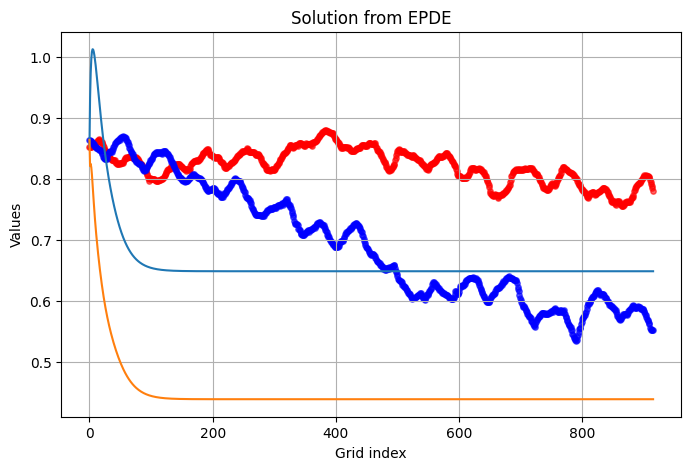

In [186]:
import matplotlib.pyplot as plt
x1 = x[boundaries[0]:boundaries[1]]
y1 = y[boundaries[0]:boundaries[1]]


plt.figure(figsize=(8, 5))
plt.scatter(t1, x1, color='red', s=15, alpha=0.6, label='True x1')
plt.scatter(t1, y1, color='blue', s=15, alpha=0.6, label='True y1')
plt.plot(solution1)           # рисует все ряды
plt.title('Solution from EPDE')
plt.xlabel('Grid index')
plt.ylabel('Values')
plt.grid(True)
plt.show()

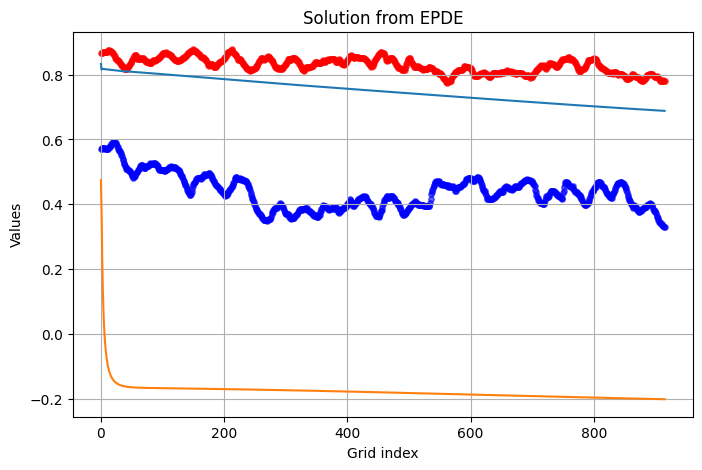

In [57]:
import matplotlib.pyplot as plt
x1 = x[boundaries[0]:boundaries[1]]
y1 = y[boundaries[0]:boundaries[1]]


plt.figure(figsize=(8, 5))
plt.scatter(t1, x1, color='red', s=15, alpha=0.6, label='True x1')
plt.scatter(t1, y1, color='blue', s=15, alpha=0.6, label='True y1')
plt.plot(solution1)           # рисует все ряды
plt.title('Solution from EPDE')
plt.xlabel('Grid index')
plt.ylabel('Values')
plt.grid(True)
plt.show()


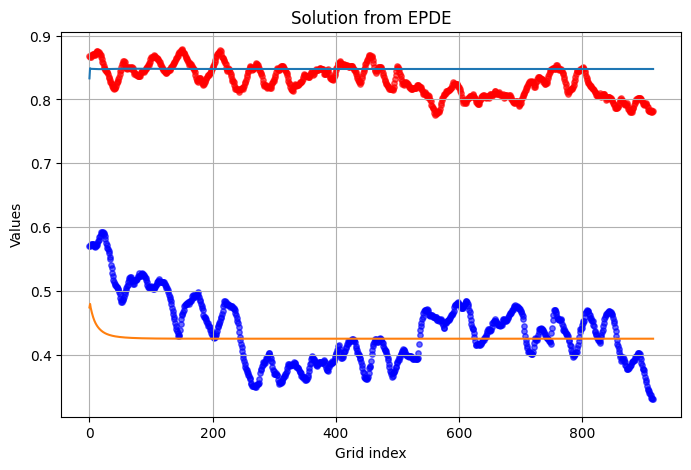

In [37]:
import matplotlib.pyplot as plt
x1 = x[boundaries[0]:boundaries[1]]
y1 = y[boundaries[0]:boundaries[1]]


plt.figure(figsize=(8, 5))
plt.scatter(t1, x1, color='red', s=15, alpha=0.6, label='True x1')
plt.scatter(t1, y1, color='blue', s=15, alpha=0.6, label='True y1')
plt.plot(solution1)           # рисует все ряды
plt.title('Solution from EPDE')
plt.xlabel('Grid index')
plt.ylabel('Values')
plt.grid(True)
plt.show()


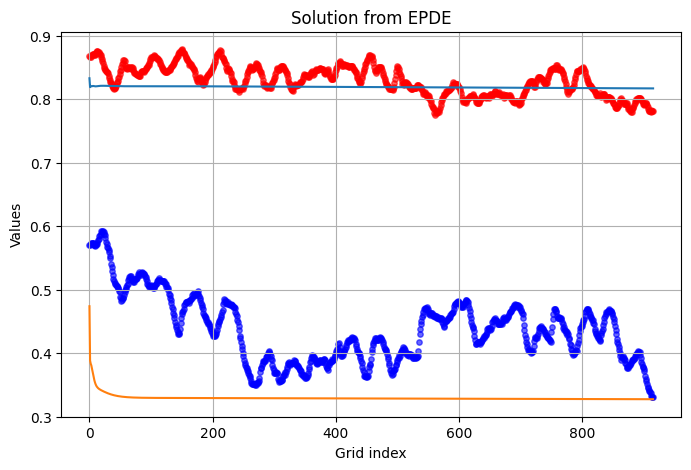

In [26]:
import matplotlib.pyplot as plt
x1 = x[boundaries[0]:boundaries[1]]
y1 = y[boundaries[0]:boundaries[1]]


plt.figure(figsize=(8, 5))
plt.scatter(t1, x1, color='red', s=15, alpha=0.6, label='True x1')
plt.scatter(t1, y1, color='blue', s=15, alpha=0.6, label='True y1')
plt.plot(solution1)           # рисует все ряды
plt.title('Solution from EPDE')
plt.xlabel('Grid index')
plt.ylabel('Values')
plt.grid(True)
plt.show()


In [56]:
import sys
import os
import logging
from pathlib import Path
from typing import Dict, List, Tuple, Any, Union
from copy import copy

import dill as pickle
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import epde
from epde.integrate.pinn_integration import SolverAdapter
from scipy import stats
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Configure logging to provide detailed execution information
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


class RobotDataProcessor:
    """Handles loading, processing, and normalizing robot movement data."""

    def __init__(self, data_path: Path):
        self.data_path = data_path
        self.raw_data = None
        self.coord_data: Dict[int, List] = {}
        self.normalized_coord_data: Dict[int, np.ndarray] = {}
        self.keys_list: List[int] = []

    def load_data(self, pickle_filename: str) -> None:
        """Loads data from a specified pickle file."""
        pickle_file = self.data_path / pickle_filename
        try:
            with open(pickle_file, 'rb') as f:
                self.raw_data = pickle.load(f)
            logger.info(f"Successfully loaded data from {pickle_file}")
        except FileNotFoundError:
            logger.error(f"File not found: {pickle_file}")
            raise
        except Exception as e:
            logger.error(f"An error occurred while loading data: {e}")
            raise

    def extract_coordinates(self) -> None:
        """Extracts coordinate data from the loaded raw data structure."""
        if self.raw_data is None:
            raise ValueError("Data not loaded. Call load_data() first.")

        self.keys_list = [inner_list[0] for inner_list in self.raw_data[0]]
        for inner_list in self.raw_data:
            for item in inner_list:
                key, _, coordinates = item
                if key in self.coord_data:
                    self.coord_data[key].append(coordinates)
                else:
                    self.coord_data[key] = [coordinates]

    @staticmethod
    def _normalize_to_normal(data: np.ndarray) -> np.ndarray:
        """
        Normalizes data by applying a Box-Cox transformation followed by Min-Max scaling.
        This helps to stabilize variance and make the data more normal-distribution-like.
        """
        # Ensure data is positive for Box-Cox transformation
        if np.min(data) <= 0:
            data = data - np.min(data) + 1e-6

        transformed_data, _ = stats.boxcox(data)
        scaler = MinMaxScaler(feature_range=(0, 1))
        return scaler.fit_transform(transformed_data.reshape(-1, 1)).flatten()

    def normalize_all_coordinates(self) -> None:
        """Normalizes all extracted x and y coordinates."""
        all_x = [point[0] for points_list in self.coord_data.values() for point in points_list]
        all_y = [point[1] for points_list in self.coord_data.values() for point in points_list]

        x_normalized = self._normalize_to_normal(np.array(all_x))
        y_normalized = self._normalize_to_normal(np.array(all_y))

        current_idx = 0
        for obj_id, points in self.coord_data.items():
            num_points = len(points)
            obj_x_norm = x_normalized[current_idx:current_idx + num_points]
            obj_y_norm = y_normalized[current_idx:current_idx + num_points]

            self.normalized_coord_data[obj_id] = np.column_stack((obj_x_norm, obj_y_norm))
            current_idx += num_points

    def get_trajectory(self, object_id: int, frequency: int = 1, max_points: int = 2750) -> Tuple[
        np.ndarray, np.ndarray, np.ndarray]:
        """Retrieves the trajectory for a specific object."""
        if object_id not in self.normalized_coord_data:
            raise ValueError(f"Object with ID {object_id} not found.")

        coords = self.normalized_coord_data[object_id][:max_points:frequency]
        x_coords = coords[:, 0]
        y_coords = coords[:, 1]
        time_points = np.arange(len(coords))
        return x_coords, y_coords, time_points

    @staticmethod
    def split_trajectory(t: np.ndarray, x: np.ndarray, y: np.ndarray, num_segments: int = 3) -> List[
        Tuple[np.ndarray, np.ndarray, np.ndarray]]:
        """Splits a trajectory into a specified number of segments."""
        total_points = len(t)
        segment_size = total_points // num_segments
        segments = []
        for i in range(num_segments):
            start_idx = i * segment_size
            end_idx = (i + 1) * segment_size if i < num_segments - 1 else total_points
            segments.append((t[start_idx:end_idx], x[start_idx:end_idx], y[start_idx:end_idx]))
        return segments


class EquationAnalyzer:
    """Loads and analyzes equation coefficients from CSV files."""

    def __init__(self, data_path: Path):
        self.data_path = data_path
        self.df: pd.DataFrame = pd.DataFrame()
        self.monte_carlo_samples: pd.DataFrame = pd.DataFrame()

    def load_equation_data(self, csv_filenames: List[str]) -> None:
        """Loads and concatenates equation data from multiple CSV files."""
        dfs = []
        for filename in csv_filenames:
            csv_path = self.data_path / filename
            try:
                df = pd.read_csv(csv_path, index_col='Unnamed: 0').drop(columns=['count'], errors='ignore').fillna(0)
                dfs.append(df)
                logger.info(f"Successfully loaded equation data from {csv_path}")
            except FileNotFoundError:
                logger.error(f"Equation file not found: {csv_path}")
                raise

        if dfs:
            self.df = pd.concat(dfs, ignore_index=True)
            logger.info(f"Combined equation data shape: {self.df.shape}")
        else:
            raise ValueError("No equation data found to concatenate.")

    def analyze_equation_patterns(self) -> None:
        """Analyzes patterns in the equation coefficients."""
        if self.df.empty:
            raise ValueError("Equation data is not loaded.")

        most_common_structure = self.df.groupby(self.df.columns.tolist()).size().reset_index(
            name='count').sort_values(by='count', ascending=False)
        logger.info(f"Most common equation structure:\n{most_common_structure.head(1)}")

        zero_patterns = (self.df == 0).astype(int).astype(str).agg(''.join, axis=1)
        pattern_counts = zero_patterns.value_counts()
        logger.info(f"Most common zero-coefficient pattern: {pattern_counts.idxmax()} "
                    f"(appears {pattern_counts.max()} times)")

    def normalize_and_filter_equations(self) -> None:
        """Normalizes and filters the equation data, handling columns with zero variance."""
        scaler = StandardScaler()
        # Find columns with non-zero variance
        valid_cols = self.df.columns[(self.df != 0).any(axis=0)]
        if valid_cols.empty:
            logger.warning("All columns have zero variance after initial filtering. Skipping scaling.")
            return

        # Filter the DataFrame to only include these columns
        self.df = self.df[valid_cols]

        scaled_values = scaler.fit_transform(self.df.values)
        normalized_df = pd.DataFrame(scaled_values, columns=self.df.columns, index=self.df.index).fillna(0)

        # Re-filter based on the specified condition
        self.df = normalized_df.loc[(normalized_df.sum(axis=1) != -1)]
        logger.info(f"Filtered equation data shape: {self.df.shape}")

    def generate_monte_carlo_samples(self, num_samples: int = 100) -> pd.DataFrame:
        """Generates new coefficient samples using a Monte Carlo method."""
        samples_df = pd.DataFrame(np.zeros((num_samples, len(self.df.columns))),
                                  columns=self.df.columns)

        for column in self.df.columns:
            mean_val, std_dev = self.df[column].mean(), self.df[column].std()
            min_val, max_val = self.df[column].min(), self.df[column].max()

            for i in range(num_samples):
                current_mean = self.df[column].iloc[i % len(self.df)]
                noise = np.random.normal(loc=0, scale=std_dev * 0.01)
                sample = np.clip(current_mean + noise, min_val, max_val)
                samples_df.loc[i, column] = sample

        logger.info(f"Generated Monte Carlo samples with shape {samples_df.shape}")
        return samples_df

    def find_similar_coefficients(self, samples_df: pd.DataFrame, threshold: float = 1.0) -> pd.DataFrame:
        """Finds generated coefficients that are similar to the original ones."""
        if self.df.empty or samples_df.empty:
            raise ValueError("DataFrames for comparison are empty.")

        distances = pairwise_distances(self.df, samples_df)
        similar_rows_indices = np.where(distances < threshold)[1]
        similar_coefficients_df = samples_df.iloc[np.unique(similar_rows_indices)]

        logger.info(f"Found {len(similar_coefficients_df)} similar coefficient sets.")
        return similar_coefficients_df


class EquationConstructor:
    """
    Constructs equation dictionaries from a DataFrame of coefficients.
    """

    @staticmethod
    def _create_equation_term(row: pd.Series) -> Dict:
        """Helper function to create a single equation dictionary from a row of coefficients."""
        return {
            # --- Terms for X equation ---
            'C_x': {'coeff': row.get('C_x', 0), 'term': [[None]], 'pow': [1], 'var': [0]},
            'x_x': {'coeff': row.get('x{power: 1.0}_x', 0), 'term': [[None]], 'pow': [1], 'var': [0]},
            'y_x': {'coeff': row.get('y{power: 1.0}_x', 0), 'term': [[None]], 'pow': [1], 'var': [1]},
            'dx/dt_x': {'coeff': row.get('dx/dx0{power: 1.0}_x', 0), 'term': [[0]], 'pow': [1], 'var': [0]},
            'd^2x/dt^2_x': {'coeff': row.get('d^2x/dx0^2{power: 1.0}_x', 0), 'term': [[0, 0]], 'pow': [1], 'var': [0]},
            'dy/dt_x': {'coeff': row.get('dy/dx0{power: 1.0}_x', 0), 'term': [[0]], 'pow': [1], 'var': [1]},
            'd^2y/dt^2_x': {'coeff': row.get('d^2y/dx0^2{power: 1.0}_x', 0), 'term': [[0, 0]], 'pow': [1], 'var': [1]},
            't_x': {'coeff': row.get('t{power: 1.0, dim: 0.0}_x', 0), 'term': [[None]], 'pow': [1], 'var': [0],
                    'grid_term': True},
            't^2_x': {'coeff': row.get('t{power: 2.0, dim: 0.0}_x', 0), 'term': [[None]], 'pow': [2], 'var': [0],
                      'grid_term': True},

            # --- Terms for Y equation ---
            'C_y': {'coeff': row.get('C_y', 0), 'term': [[None]], 'pow': [1], 'var': [0]},
            'x_y': {'coeff': row.get('x{power: 1.0}_y', 0), 'term': [[None]], 'pow': [1], 'var': [0]},
            'y_y': {'coeff': row.get('y{power: 1.0}_y', 0), 'term': [[None]], 'pow': [1], 'var': [1]},
            'dx/dt_y': {'coeff': row.get('dx/dx0{power: 1.0}_y', 0), 'term': [[0]], 'pow': [1], 'var': [0]},
            'd^2x/dt^2_y': {'coeff': row.get('d^2x/dx0^2{power: 1.0}_y', 0), 'term': [[0, 0]], 'pow': [1], 'var': [0]},
            'dy/dt_y': {'coeff': row.get('dy/dx0{power: 1.0}_y', 0), 'term': [[0]], 'pow': [1], 'var': [1]},
            'd^2y/dt^2_y': {'coeff': row.get('d^2y/dx0^2{power: 1.0}_y', 0), 'term': [[0, 0]], 'pow': [1], 'var': [1]},
            't_y': {'coeff': row.get('t{power: 1.0, dim: 0.0}_y', 0), 'term': [[None]], 'pow': [1], 'var': [0],
                    'grid_term': True},
            't^2_y': {'coeff': row.get('t{power: 2.0, dim: 0.0}_y', 0), 'term': [[None]], 'pow': [2], 'var': [0],
                      'grid_term': True},

            # --- Composite terms for X equation ---
            'x*dx/dt_x': {'coeff': row.get('x{power: 1.0} * dx/dx0{power: 1.0}_x', 0), 'term': [[None], [0]],
                          'pow': [1, 1], 'var': [0, 0]},
            'y*dy/dt_x': {'coeff': row.get('y{power: 1.0} * dy/dx0{power: 1.0}_x', 0), 'term': [[None], [0]],
                          'pow': [1, 1], 'var': [1, 1]},
            'dx/dt*dy/dt_x': {'coeff': row.get('dx/dx0{power: 1.0} * dy/dx0{power: 1.0}_x', 0), 'term': [[0], [0]],
                              'pow': [1, 1], 'var': [0, 1]},
            'dx/dt*d^2x/dt^2_x': {'coeff': row.get('dx/dx0{power: 1.0} * d^2x/dx0^2{power: 1.0}_x', 0),
                                  'term': [[0], [0, 0]], 'pow': [1, 1], 'var': [0, 0]},
            'dx/dt*d^2y/dt^2_x': {'coeff': row.get('dx/dx0{power: 1.0} * d^2y/dx0^2{power: 1.0}_x', 0),
                                  'term': [[0], [0, 0]], 'pow': [1, 1], 'var': [0, 1]},
            'dx/dt*t_x': {'coeff': row.get('dx/dx0{power: 1.0} * t{power: 1.0, dim: 0.0}_x', 0), 'term': [[0], [None]],
                          'pow': [1, 1], 'var': [0, 0], 'grid_term': [False, True]},
            'd^2y/dt^2*t_x': {'coeff': row.get('d^2y/dx0^2{power: 1.0} * t{power: 1.0, dim: 0.0}_x', 0),
                              'term': [[0, 0], [None]], 'pow': [1, 1], 'var': [1, 0], 'grid_term': [False, True]},
            'd^2y/dt^2*sin_x': {'coeff': row.get('d^2y/dx0^2{power: 1.0} * sin{power: 1.0, dim: 0.0}_x', 0),
                                'term': [[0, 0], [None]], 'pow': [1, 1], 'var': [1, 0], 'like_grad': [False, True]},

            # --- Composite terms for Y equation ---
            'y*d^2y/dt^2_y': {'coeff': row.get('y{power: 1.0} * d^2y/dx0^2{power: 1.0}_y', 0), 'term': [[None], [0, 0]],
                              'pow': [1, 1], 'var': [1, 1]},
            'dy/dt*x_y': {'coeff': row.get('dy/dx0{power: 1.0} * x{power: 1.0}_y', 0), 'term': [[0], [None]],
                          'pow': [1, 1], 'var': [1, 0]},
            'dy/dt*dx/dt_y': {'coeff': row.get('dy/dx0{power: 1.0} * dx/dx0{power: 1.0}_y', 0), 'term': [[0], [0]],
                              'pow': [1, 1], 'var': [1, 0]},
            'dy/dt*d^2x/dt^2_y': {'coeff': row.get('dy/dx0{power: 1.0} * d^2x/dx0^2{power: 1.0}_y', 0),
                                  'term': [[0], [0, 0]], 'pow': [1, 1], 'var': [1, 0]},
            'd^2x/dt^2*d^2y/dt^2_y': {'coeff': row.get('d^2x/dx0^2{power: 1.0} * d^2y/dx0^2{power: 1.0}_y', 0),
                                      'term': [[0, 0], [0, 0]], 'pow': [1, 1], 'var': [0, 1]},
            't*d^2y/dt^2_y': {'coeff': row.get('t{power: 1.0, dim: 0.0} * d^2y/dx0^2{power: 1.0}_y', 0),
                              'term': [[None], [0, 0]], 'pow': [1, 1], 'var': [0, 1], 'grid_term': [True, False]},
            't^2*y_y': {'coeff': row.get('t{power: 2.0, dim: 0.0} * y{power: 1.0}_y', 0), 'term': [[None], [None]],
                        'pow': [2, 1], 'var': [0, 1], 'grid_term': [True, False]},
            'dx/dt*sin_y': {'coeff': row.get('dx/dx0{power: 1.0} * sin{power: 1.0, dim: 0.0}_y', 0),
                            'term': [[0], [None]], 'pow': [1, 1], 'var': [0, 0], 'like_grad': [False, True]},
            'dx/dt*cos_y': {'coeff': row.get('dx/dx0{power: 1.0} * cos{power: 1.0, dim: 0.0}_y', 0),
                            'term': [[0], [None]], 'pow': [1, 1], 'var': [0, 0], 'like_grad': [False, True]},
        }

    def construct_equation_systems(self, coefficients_df: pd.DataFrame) -> List[Tuple[Dict, Dict]]:
        """Constructs a list of equation system dictionaries from a DataFrame of coefficients."""
        equation_systems = []
        for _, row in coefficients_df.iterrows():
            full_equation = self._create_equation_term(row)

            eq_x = {key: val for key, val in full_equation.items() if '_x' in key and val['coeff'] != 0}
            eq_y = {key: val for key, val in full_equation.items() if '_y' in key and val['coeff'] != 0}

            equation_systems.append((eq_x, eq_y))
        return equation_systems


class ODESolver:
    """Solves systems of Ordinary Differential Equations using a PINN-based adapter."""

    def __init__(self):
        self.adapter = SolverAdapter()
        # Configure solver parameters for better performance
        self.adapter.change_parameter('epochs', 5000)
        self.adapter.change_parameter('optimizer', 'LBFGS')

    @staticmethod
    def create_boundary_operator(key: str, var_idx: int, term: Union[int, List], grid_loc: float, value: float) -> Dict[
        str, Any]:
        """Creates a boundary operator dictionary required by the solver."""
        if not isinstance(term, list):
            term = [term]
        bop = epde.integrate.BOPElement(axis=0, key=key, term=term, power=1, var=var_idx)
        bop.set_grid(torch.from_numpy(np.array([[grid_loc]])).float())
        bop.values = torch.from_numpy(np.array([[value]])).float()
        return {
            'bnd_loc': torch.Tensor([bop.location, ]),
            'bnd_op': {bop.operator_form[0]: bop.operator_form[1]},
            'bnd_val': bop.values
        }

    def solve_system(self, equations: Dict, grids: List, boundary_conditions: List) -> Any:
        """Solves a system of ODEs."""
        try:
            _, solution = self.adapter.solve_epde_system(
                system=equations,
                grids=grids,
                boundary_conditions=boundary_conditions,
                mode='NN',
                to_numpy=True,
                grid_var_keys=['t']
            )
            logger.info("ODE system solved successfully.")
            return solution
        except Exception as e:
            logger.error(f"Error while solving ODE system: {e}")
            return None


class SolutionManager:
    """Manages saving solutions and coefficients to files."""

    def __init__(self, output_path: Path):
        self.output_path = output_path
        os.makedirs(output_path, exist_ok=True)

    def save_solution(self, solution: np.ndarray, time_points: np.ndarray, object_id: int, part_idx: int) -> None:
        """Saves a trajectory segment solution to a CSV file."""
        df = pd.DataFrame({'t': time_points, 'x': solution[:, 0], 'y': solution[:, 1]})
        filename = self.output_path / f'solution_{object_id}_part_{part_idx + 1}.csv'
        df.to_csv(filename, index=False)
        logger.info(f"Solution segment saved to {filename}")

    def save_combined_solution(self, solutions: List[np.ndarray], time_points: np.ndarray, object_id: int) -> None:
        """Saves the combined trajectory solution to a CSV file."""
        combined_solution = np.vstack(solutions)
        df = pd.DataFrame({'t': time_points, 'x': combined_solution[:, 0], 'y': combined_solution[:, 1]})
        filename = self.output_path / f'solution_{object_id}_combined.csv'
        df.to_csv(filename, index=False)
        logger.info(f"Combined solution saved to {filename}")

    def save_equation_coefficients(self, equations: List[Tuple[Dict, Dict]], object_id: int) -> None:
        """
        Saves the coefficients of the discovered equations.
        Expects a list of tuples, where each tuple contains two equation dictionaries.
        """
        coeff_data = []
        for i, eq_tuple in enumerate(equations):
            eq_x, eq_y = eq_tuple[0], eq_tuple[1]

            # Process the X-equation
            for term_name, term_params in eq_x.items():
                coeff_data.append({
                    'equation_set': i + 1,
                    'equation_type': 'x',
                    'term_name': term_name,
                    'coefficient': term_params['coeff']
                })

            # Process the Y-equation
            for term_name, term_params in eq_y.items():
                coeff_data.append({
                    'equation_set': i + 1,
                    'equation_type': 'y',
                    'term_name': term_name,
                    'coefficient': term_params['coeff']
                })

        df = pd.DataFrame(coeff_data)
        filename = self.output_path / f'coefficients_{object_id}.csv'
        df.to_csv(filename, index=False)
        logger.info(f"Equation coefficients saved to {filename}")

    def save_numpy_and_tensor(self, data: np.ndarray, filename: str) -> None:
        """Saves a numpy array as a .npy file and a PyTorch tensor."""
        numpy_path = self.output_path / (filename + '.npy')
        torch_path = self.output_path / (filename + '.pt')

        np.save(numpy_path, data)
        torch.save(torch.from_numpy(data).float(), torch_path)
        logger.info(f"Solution saved in .npy and .pt formats: {numpy_path}, {torch_path}")


def average_solutions(solutions_list: List[np.ndarray]) -> Tuple[np.ndarray, np.ndarray]:
    """Calculates the element-wise average and standard deviation of a list of solutions."""
    if not solutions_list:
        return np.array([]), np.array([])

    # Pad solutions with NaNs to make them all the same length
    max_len = max(sol.shape[0] for sol in solutions_list)
    padded_solutions = np.array(
        [np.pad(sol, ((0, max_len - sol.shape[0]), (0, 0)), 'constant', constant_values=np.nan) for sol in
         solutions_list])

    # Calculate the mean and std, ignoring NaNs
    mean_solution = np.nanmean(padded_solutions, axis=0)
    std_solution = np.nanstd(padded_solutions, axis=0)

    return mean_solution, std_solution


def main():
    """Main function to execute the entire robot trajectory analysis workflow."""
    # --- Configuration ---
    DATA_PATH = Path(r'/Users/20s_a02/Documents/НИР/программа/Active_Matter')
    OUTPUT_PATH = DATA_PATH / 'output'
    PICKLE_FILENAME = 'data_00_330_[30_bots_PWM_10_15cw_15ccw_D_41cm].MP4.pickle'
    OBJECT_ID = 78
    FREQUENCY = 1
    MAX_POINTS = 2750
    NUM_SEGMENTS = 3
    NUM_MONTE_CARLO_SAMPLES = 1  # Number of different equation systems to solve

    CSV_FILENAMES = [f'output_{OBJECT_ID}_part_{i}.csv' for i in range(1, NUM_SEGMENTS + 1)]

    try:
        # --- 1. Data Loading and Preprocessing ---
        logger.info("--- Stage 1: Processing Robot Movement Data ---")
        data_processor = RobotDataProcessor(DATA_PATH)
        data_processor.load_data(PICKLE_FILENAME)
        data_processor.extract_coordinates()
        data_processor.normalize_all_coordinates()
        x_full, y_full, t_full = data_processor.get_trajectory(OBJECT_ID, FREQUENCY, MAX_POINTS)
        segments = data_processor.split_trajectory(t_full, x_full, y_full, num_segments=NUM_SEGMENTS)

        # --- 2. Equation Analysis and Coefficient Generation ---
        logger.info("--- Stage 2: Analyzing Equations ---")
        equation_analyzer = EquationAnalyzer(DATA_PATH / 'output')
        equation_analyzer.load_equation_data(CSV_FILENAMES)
        equation_analyzer.analyze_equation_patterns()
        equation_analyzer.normalize_and_filter_equations()

        # --- 3. Equation Construction and Solver setup ---
        logger.info("--- Stage 3: Preparing for Monte Carlo Simulations ---")
        equation_constructor = EquationConstructor()
        ode_solver = ODESolver()
        solution_manager = SolutionManager(OUTPUT_PATH)

        # Lists to store solutions from all Monte Carlo runs
        all_mc_solutions = []

        # --- 4. Monte Carlo Simulation Loop ---
        logger.info(f"--- Stage 4: Solving ODE System for {NUM_MONTE_CARLO_SAMPLES} Monte Carlo Samples ---")
        for i in range(NUM_MONTE_CARLO_SAMPLES):
            logger.info(f"--- Starting Monte Carlo Run {i + 1}/{NUM_MONTE_CARLO_SAMPLES} ---")

            # Generate new coefficients for this run
            monte_carlo_samples_df = equation_analyzer.generate_monte_carlo_samples(num_samples=1)

            # Find similar coefficients (or use the generated one if no similarity is found)
            similar_coefficients_df = equation_analyzer.find_similar_coefficients(monte_carlo_samples_df)
            if similar_coefficients_df.empty:
                similar_coefficients_df = monte_carlo_samples_df

            equation_systems = equation_constructor.construct_equation_systems(similar_coefficients_df)

            # Store coefficients for this run
            solution_manager.save_equation_coefficients(equation_systems, f'{OBJECT_ID}_mc_run_{i+1}')

            current_run_solutions = []
            for seg_idx, (t_seg, x_seg, y_seg) in enumerate(segments):
                x0, y0 = (x_seg[0], y_seg[0]) if seg_idx == 0 else (
                current_run_solutions[-1][-1, 0], current_run_solutions[-1][-1, 1])

                b_op_x = ode_solver.create_boundary_operator('x', 0, [None], t_seg[0]-1, x0)
                b_op_y = ode_solver.create_boundary_operator('y', 1, [None], t_seg[0]-1, y0)

                # Use the first equation set from the generated list
                equation_set = equation_systems[0]

                solution = ode_solver.solve_system(
                    equations={'x': equation_set[0], 'y': equation_set[1]},
                    grids=[torch.from_numpy(t_seg).float()],
                    boundary_conditions=[b_op_y, b_op_x]
                )

                if solution is not None:
                    current_run_solutions.append(solution)
                else:
                    logger.warning(f"Solution for segment {seg_idx + 1} failed. Skipping this run.")
                    current_run_solutions = []
                    break  # Break out of the segment loop for this run

            if current_run_solutions:
                combined_run_solution = np.vstack(current_run_solutions)
                all_mc_solutions.append(combined_run_solution)

        if not all_mc_solutions:
            logger.error("No successful Monte Carlo simulations were completed. Exiting.")
            return

        # --- 5. Averaging Solutions and Final Output ---
        logger.info("--- Stage 5: Averaging Solutions and Saving Results ---")
        avg_solution, std_solution = average_solutions(all_mc_solutions)

        # Save the average solution as a numpy array and tensor
        solution_manager.save_numpy_and_tensor(avg_solution, f'average_solution_{OBJECT_ID}')
        solution_manager.save_numpy_and_tensor(std_solution, f'std_deviation_solution_{OBJECT_ID}')

        # Save the combined average solution to a CSV for plotting
        df_avg = pd.DataFrame({'t': t_full[:len(avg_solution)], 'x': avg_solution[:, 0], 'y': avg_solution[:, 1]})
        df_avg.to_csv(OUTPUT_PATH / f'average_solution_{OBJECT_ID}_combined.csv', index=False)
        logger.info(f"Average solution saved to {OUTPUT_PATH / f'average_solution_{OBJECT_ID}_combined.csv'}")

        # Visualize the average solution with original data and uncertainty
        plt.figure(figsize=(12, 8))
        plt.plot(t_full, avg_solution[:, 0], label='x (average solution)')
        plt.plot(t_full, avg_solution[:, 1], label='y (average solution)')
        plt.fill_between(t_full[:len(avg_solution)], avg_solution[:, 0] - std_solution[:, 0],
                         avg_solution[:, 0] + std_solution[:, 0], alpha=0.2, label='x uncertainty')
        plt.fill_between(t_full[:len(avg_solution)], avg_solution[:, 1] - std_solution[:, 1],
                         avg_solution[:, 1] + std_solution[:, 1], alpha=0.2, label='y uncertainty')
        plt.plot(t_full, x_full, '--', label='x (original data)', alpha=0.7)
        plt.plot(t_full, y_full, '--', label='y (original data)', alpha=0.7)
        plt.title(f'Combined Average Solution for Object {OBJECT_ID}')
        plt.xlabel('Time')
        plt.ylabel('Coordinates')
        plt.legend()
        plt.savefig(OUTPUT_PATH / f'average_combined_solution_{OBJECT_ID}.png')
        plt.close()

        # Plot the standard deviation for x and y separately
        plt.figure(figsize=(12, 6))
        plt.plot(t_full[:len(std_solution)], std_solution[:, 0], label='x std dev')
        plt.plot(t_full[:len(std_solution)], std_solution[:, 1], label='y std dev')
        plt.title('Standard Deviation of Solutions over Time')
        plt.xlabel('Time')
        plt.ylabel('Standard Deviation')
        plt.legend()
        plt.savefig(OUTPUT_PATH / f'std_deviation_plot_{OBJECT_ID}.png')
        plt.close()

        # Calculate final MSE with the average solution
        avg_solution_len = min(len(avg_solution), len(x_full))
        mse_x = np.mean((avg_solution[:avg_solution_len, 0] - x_full[:avg_solution_len]) ** 2)
        mse_y = np.mean((avg_solution[:avg_solution_len, 1] - y_full[:avg_solution_len]) ** 2)
        logger.info(f"Final Mean Squared Error (vs. Average Solution): x={mse_x:.6f}, y={mse_y:.6f}")
        logger.info("Workflow completed successfully.")

    except Exception as e:
        logger.error(f"A critical error occurred in the main workflow: {e}", exc_info=True)


if __name__ == "__main__":
    main()
    


2025-09-24 15:33:47,857 - INFO - --- Stage 1: Processing Robot Movement Data ---
2025-09-24 15:33:48,153 - INFO - Successfully loaded data from /Users/20s_a02/Documents/НИР/программа/Active_Matter/data_00_330_[30_bots_PWM_10_15cw_15ccw_D_41cm].MP4.pickle
2025-09-24 15:33:48,967 - INFO - --- Stage 2: Analyzing Equations ---
2025-09-24 15:33:48,971 - INFO - Successfully loaded equation data from /Users/20s_a02/Documents/НИР/программа/Active_Matter/output/output_78_part_1.csv
2025-09-24 15:33:48,972 - INFO - Successfully loaded equation data from /Users/20s_a02/Documents/НИР/программа/Active_Matter/output/output_78_part_2.csv
2025-09-24 15:33:48,973 - INFO - Successfully loaded equation data from /Users/20s_a02/Documents/НИР/программа/Active_Matter/output/output_78_part_3.csv
2025-09-24 15:33:48,974 - INFO - Combined equation data shape: (18, 30)
2025-09-24 15:33:48,988 - INFO - Most common equation structure:
Empty DataFrame
Columns: [y{power: 1.0}_x, C_x, dx/dx0{power: 1.0} * x{power: 1

KeyboardInterrupt: 